Found 26291 images belonging to 26 classes.
Found 7415 images belonging to 26 classes.
Detected Classes: {'a': 0, 'b': 1, 'c': 2, 'd': 3, 'e': 4, 'f': 5, 'g': 6, 'h': 7, 'i': 8, 'j': 9, 'k': 10, 'l': 11, 'm': 12, 'n': 13, 'o': 14, 'p': 15, 'q': 16, 'r': 17, 's': 18, 't': 19, 'u': 20, 'v': 21, 'w': 22, 'x': 23, 'y': 24, 'z': 25}
Epoch 1/20
822/822 ━━━━━━━━━━━━━━━━━━━━ 0s 371ms/step - accuracy: 0.8052 - loss: 0.7666

822/822 ━━━━━━━━━━━━━━━━━━━━ 331s 394ms/step - accuracy: 0.9201 - loss: 0.3131 - val_accuracy: 0.9804 - val_loss: 0.0658
Epoch 2/20
822/822 ━━━━━━━━━━━━━━━━━━━━ 0s 352ms/step - accuracy: 0.9815 - loss: 0.0649

822/822 ━━━━━━━━━━━━━━━━━━━━ 302s 367ms/step - accuracy: 0.9837 - loss: 0.0573 - val_accuracy: 0.9891 - val_loss: 0.0393
Epoch 3/20
822/822 ━━━━━━━━━━━━━━━━━━━━ 301s 366ms/step - accuracy: 0.9867 - loss: 0.0428 - val_accuracy: 0.9833 - val_loss: 0.0530
Epoch 4/20
822/822 ━━━━━━━━━━━━━━━━━━━━ 301s 365ms/step - accuracy: 0.9897 - loss: 0.0322 - val_accuracy: 0.9852 - val_loss: 0.0416
Epoch 5/20
822/822 ━━━━━━━━━━━━━━━━━━━━ 298s 363ms/step - accuracy: 0.9896 - loss: 0.0314 - val_accuracy: 0.9841 - val_loss: 0.0477


232/232 ━━━━━━━━━━━━━━━━━━━━ 18s 62ms/step


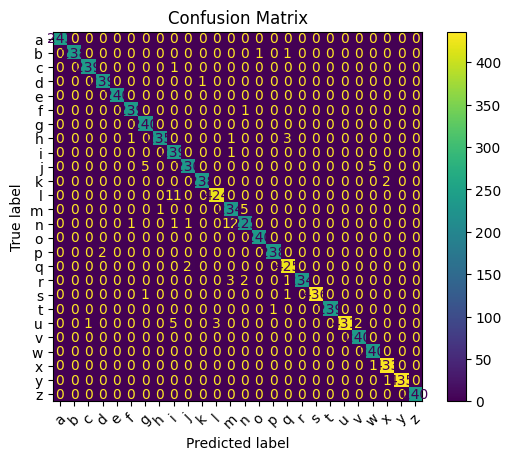

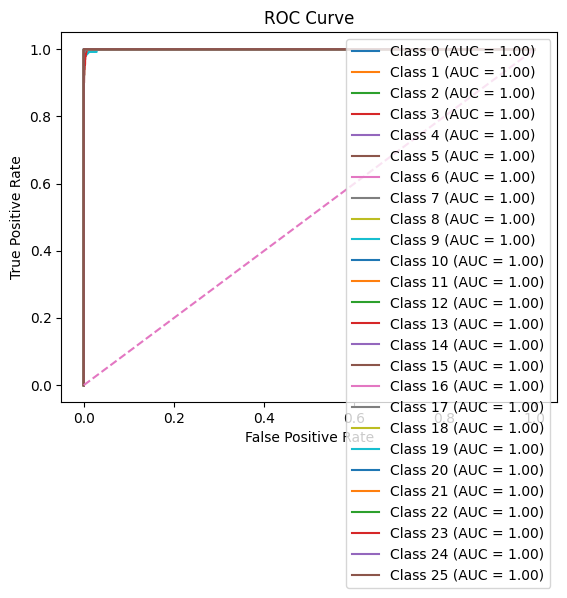

In [7]:
import os
import numpy as np
import tensorflow as tf
import matplotlib.pyplot as plt
from PIL import Image
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay, roc_curve, auc
from sklearn.preprocessing import label_binarize

# -----------------------------
# 1. REMOVE CORRUPTED IMAGES
# -----------------------------
def remove_corrupted_images(directory):
    for root, dirs, files in os.walk(directory):
        for file in files:
            path = os.path.join(root, file)
            try:
                img = Image.open(path)
                img.verify()
            except:
                print("Removing corrupted:", path)
                os.remove(path)

remove_corrupted_images('/content/unzipped_data/train')
remove_corrupted_images('/content/unzipped_data/val')

# -----------------------------
# 2. DATA GENERATOR
# -----------------------------
from tensorflow.keras.preprocessing.image import ImageDataGenerator

train_datagen = ImageDataGenerator(
    rescale=1./255,
    rotation_range=20,
    zoom_range=0.2,
    horizontal_flip=True
)

val_datagen = ImageDataGenerator(rescale=1./255)

train_data = train_datagen.flow_from_directory(
    '/content/unzipped_data/train',
    target_size=(224,224),
    batch_size=32,
    class_mode='categorical',
    shuffle=True
)

val_data = val_datagen.flow_from_directory(
    '/content/unzipped_data/val',
    target_size=(224,224),
    batch_size=32,
    class_mode='categorical',
    shuffle=False
)

num_classes = len(train_data.class_indices)
print("Detected Classes:", train_data.class_indices)

# -----------------------------
# 3. MODEL (MobileNetV2)
# -----------------------------
from tensorflow.keras.applications import MobileNetV2
from tensorflow.keras.layers import Dense, GlobalAveragePooling2D
from tensorflow.keras.models import Model

base_model = MobileNetV2(weights='imagenet', include_top=False, input_shape=(224,224,3))

for layer in base_model.layers:
    layer.trainable = False

x = base_model.output
x = GlobalAveragePooling2D()(x)
x = Dense(128, activation='relu')(x)
output = Dense(num_classes, activation='softmax')(x)

model = Model(inputs=base_model.input, outputs=output)

model.compile(
    optimizer='adam',
    loss='categorical_crossentropy',
    metrics=['accuracy']
)

# -----------------------------
# 4. CALLBACKS
# -----------------------------
from tensorflow.keras.callbacks import EarlyStopping, ModelCheckpoint

early_stop = EarlyStopping(
    monitor='val_loss',
    patience=3,
    restore_best_weights=True
)

checkpoint = ModelCheckpoint(
    "best_model.h5",   # ✅ updated format
    monitor='val_accuracy',
    save_best_only=True
)

# -----------------------------
# 5. TRAIN MODEL
# -----------------------------
history = model.fit(
    train_data,
    validation_data=val_data,
    epochs=20,
    callbacks=[early_stop, checkpoint]
)

# -----------------------------
# 6. SAVE FINAL MODEL
# -----------------------------
model.save("final_model.h5")

# -----------------------------
# 7. CONFUSION MATRIX
# -----------------------------
val_data.reset()
y_pred = model.predict(val_data)
y_pred_classes = np.argmax(y_pred, axis=1)
y_true = val_data.classes

cm = confusion_matrix(
    y_true,
    y_pred_classes
)

disp = ConfusionMatrixDisplay(
    confusion_matrix=cm,
    display_labels=list(train_data.class_indices.keys())
)
disp.plot(xticks_rotation=45)
plt.title("Confusion Matrix")
plt.show()

# -----------------------------
# 8. ROC CURVE
# -----------------------------
y_true_bin = label_binarize(y_true, classes=range(num_classes))

plt.figure()

for i in range(num_classes):
    fpr, tpr, _ = roc_curve(y_true_bin[:, i], y_pred[:, i])
    roc_auc = auc(fpr, tpr)
    plt.plot(fpr, tpr, label=f'Class {i} (AUC = {roc_auc:.2f})')

plt.plot([0,1], [0,1], linestyle='--')
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve")
plt.legend()
plt.show()